# Voyage Analytics — MLflow Tracking & Model Registry

**Notebook:** `06_MLflow_Tracking` · **Pipeline stage:** `mlflow` (9th) · **Objective:** #7
**Module:** `src/mlops/tracking.py` · **Store:** `mlflow/mlruns` (local file backend)

---

### What this stage adds
Up to now every model wrote its metrics to a separate JSON file. That works for one person on one
machine, but it answers none of the questions a production team actually asks:

- Which exact parameters produced *this* score?
- Which model version is currently deployed, and which one did it replace?
- Can I compare two runs side by side, months apart?

MLflow gives one **tracking store** for runs and one **registry** for the models judged fit to serve.

### Two decisions worth stating up front

**1. Training runs *inside* the MLflow run.** Parameters are logged by the same code that produces
the metrics, so they cannot drift apart — the alternative (train first, log afterwards) is how
recorded hyperparameters end up not matching the model.

**2. Only validated models get registered.** The registry is a deployment contract — anything in it
reads as "approved to serve". A model that cannot beat chance is logged with its evidence but never
promoted, because otherwise someone downstream will find it and ship it.

| Model | Status | Registered? |
|---|---|---|
| Flight price (`gbr_rate_per_km`) | VALID — R² 0.936 [0.913, 0.960] | ✅ `voyage-flight-price` |
| Gender (`name_logistic`) | VALID — acc 0.884, p = 0.0099 | ✅ `voyage-gender-classifier` |
| Hotel ranking (item-CF) | VALID — hit@3 0.858 [0.840, 0.878] | ✅ `voyage-hotel-recommender` |
| Hotel attach | AT CHANCE — AUC 0.498 [0.495, 0.501] | ❌ logged only |

Gender moved into the registry only after first-name character n-grams took it from 0.50 to 0.88;
the behaviour-only variants remain at chance and are logged alongside for contrast. The run records
`signal_source` as a tag so nobody has to guess *why* it works.


## 0. Setup

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
PAL = ["#0B6E4F", "#F2C14E", "#B4436C", "#4C6EF5"]

import mlflow
from src.utils import PATHS
print("mlflow version:", mlflow.__version__)

mlflow version: 2.16.2


## 1. Configure the tracking store

A local **file backend** (`mlflow/mlruns`) — no server, no database, works offline. The same code
points at a remote tracking server by changing one URI, which is what a team deployment would do.

In [2]:
from src.mlops import setup_mlflow, EXPERIMENT, TRACKING_DIR

uri = setup_mlflow()
print("tracking uri :", uri)
print("experiment   :", EXPERIMENT)
print("store folder :", TRACKING_DIR.relative_to(PATHS.root))

21:25:08 | INFO    | mlops | tracking uri: file:///F:/Final%20Project%20Labmentix/voyage-analytics/mlflow/mlruns


21:25:08 | INFO    | mlops | experiment  : voyage-analytics


tracking uri : file:///F:/Final%20Project%20Labmentix/voyage-analytics/mlflow/mlruns
experiment   : voyage-analytics
store folder : mlflow\mlruns


## 2. Track every model

One call trains all three models inside MLflow runs, logging for each:

| Logged | Examples |
|---|---|
| **params** | model class, feature lists, target, excluded features and *why* |
| **metrics** | headline + per-candidate + cross-validated mean/std/CI |
| **tags** | objective number, problem type, validation method, status verdict |
| **artifacts** | the serialized pipeline, plus the metrics JSON |

Note the `excluded_features` parameter — recording *what we left out and why* (`time` for
collinearity, `route` as the group key, `name` as a gender leak) is as important as recording what
went in, and it is the first thing a reviewer asks about months later.

In [3]:
from src.mlops import run as track_all

result = track_all(register=True)
print("\ntracked runs:")
for name, info in result["tracked"].items():
    flag = "registered" if info["registrable"] else "logged only (failed validation)"
    print(f"  {name:<20} {info['run_id'][:8]}  {info['model']:<16} {flag}")
print("\nregistered models:", result["registered"] or "none")

21:25:08 | INFO    | mlops | === MLflow tracking started ===


21:25:08 | INFO    | mlops | tracking uri: file:///F:/Final%20Project%20Labmentix/voyage-analytics/mlflow/mlruns


21:25:08 | INFO    | mlops | experiment  : voyage-analytics


21:25:09 | INFO    | model.flight_price | === flight-price regression started ===


21:25:10 | INFO    | ingest | loaded flight_price_model   (271888, 10) from flight_price_model.csv


...

21:27:17 | INFO    | mlops | tracked 3 runs, registered 3 models


21:27:17 | INFO    | mlops | view with: mlflow ui --backend-store-uri mlflow/mlruns


21:27:17 | INFO    | mlops | === MLflow tracking complete ===


Registered model 'voyage-flight-price' already exists. Creating a new version of this model...
Created version '2' of model 'voyage-flight-price'.
Registered model 'voyage-gender-classifier' already exists. Creating a new version of this model...
Created version '2' of model 'voyage-gender-classifier'.
Registered model 'voyage-hotel-recommender' already exists. Creating a new version of this model...
Created version '2' of model 'voyage-hotel-recommender'.



tracked runs:
  flight_price         0133952a  gbr_rate_per_km  registered
  gender               2d982d14  name_logistic    registered
  hotel_recommender    086d0760  item_cf          registered

registered models: {'voyage-flight-price': 2, 'voyage-gender-classifier': 2, 'voyage-hotel-recommender': 2}


## 3. Inspect the tracked runs

In [4]:
from src.mlops import list_runs

runs = list_runs()
print("runs recorded:", len(runs))
cols = [c for c in runs.columns if c.startswith("tags.") and "mlflow" not in c]
display(runs[["run_id", "status"] + cols].head(10))

runs recorded: 6


,run_id,status,tags.status,tags.objective,tags.problem_type,tags.validation,tags.verdict,tags.signal_source
0,086d0760259648d392ba0cac31ca47f4,FINISHED,RANKING_VALID / ATTACH_AT_CHANCE,9 - hotel recommendation,ranking (collaborative filtering) + binary cla...,leave-one-out + bootstrap CI,None,None
1,2d982d14c7094f67a6a1d77a3f647932,FINISHED,VALID,8 - gender classification,binary classification,RepeatedStratifiedKFold + permutation test + G...,predictive from the first name: 0.8778 standar...,first-name character n-grams
2,0133952a9e344846993f47b5db399997,FINISHED,VALID,1 - flight price prediction,regression,GroupShuffleSplit + GroupKFold over routes,None,None
3,c9dd455914184490a2ef70bb1112c5c0,FINISHED,RANKING_VALID / ATTACH_AT_CHANCE,9 - hotel recommendation,ranking (collaborative filtering) + binary cla...,leave-one-out + bootstrap CI,None,None
4,4b98c69fd093470db4f1db700c4951c6,FINISHED,VALID,8 - gender classification,binary classification,RepeatedStratifiedKFold + permutation test + G...,predictive from the first name: 0.8778 standar...,first-name character n-grams
5,28afbab80c8541caa78373a342662d86,FINISHED,VALID,1 - flight price prediction,regression,GroupShuffleSplit + GroupKFold over routes,None,None


In [5]:
# Headline metric per run, with the validation verdict attached
show = []
for _, r in runs.iterrows():
    show.append({
        "run": r.get("tags.mlflow.runName"),
        "objective": r.get("tags.objective"),
        "type": r.get("tags.problem_type"),
        "status": r.get("tags.status"),
    })
display(pd.DataFrame(show))

,run,objective,type,status
0,hotel_recommender,9 - hotel recommendation,ranking (collaborative filtering) + binary cla...,RANKING_VALID / ATTACH_AT_CHANCE
1,gender_classification,8 - gender classification,binary classification,VALID
2,flight_price_regression,1 - flight price prediction,regression,VALID
3,hotel_recommender,9 - hotel recommendation,ranking (collaborative filtering) + binary cla...,RANKING_VALID / ATTACH_AT_CHANCE
4,gender_classification,8 - gender classification,binary classification,VALID
5,flight_price_regression,1 - flight price prediction,regression,VALID


## 4. Comparing runs — what the tracking store is for

Every candidate model's score is logged, not just the winner. That means the *reason* a model was
chosen stays auditable instead of living in someone's memory.

,held_out_routes,random_split
decision_tree,0.7134,0.9985
gbr_rate_per_km,0.9265,0.9999
hist_gbr,0.6985,0.9999
ridge,0.8569,0.9192


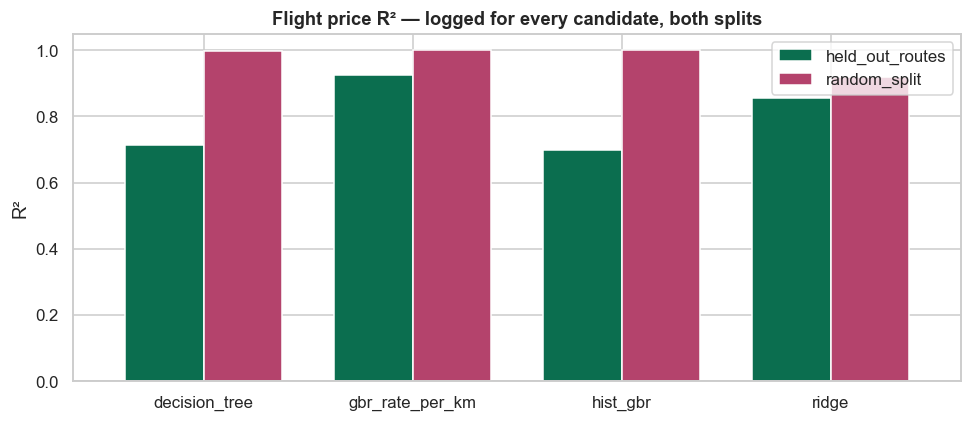

In [6]:
metric_cols = [c for c in runs.columns if c.startswith("metrics.")]
fp = runs[runs["tags.objective"].astype(str).str.startswith("1")]
if len(fp):
    row = fp.iloc[0]
    grouped = {c.replace("metrics.grouped_", ""): row[c]
               for c in metric_cols if "grouped_" in c and c.endswith("_r2")}
    random_ = {c.replace("metrics.random_", ""): row[c]
               for c in metric_cols if "random_" in c and c.endswith("_r2")}
    comp = pd.DataFrame({"held_out_routes": pd.Series(grouped),
                         "random_split": pd.Series(random_)})
    comp.index = [i.replace("_r2", "") for i in comp.index]
    display(comp.round(4))

    ax = comp.plot(kind="bar", figsize=(9, 4), color=[PAL[0], PAL[2]], width=0.75)
    ax.set_title("Flight price R² — logged for every candidate, both splits")
    ax.set_ylabel("R²"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    PATHS.figures.mkdir(parents=True, exist_ok=True)
    plt.savefig(PATHS.figures / "23_mlflow_run_comparison.png", dpi=130, bbox_inches="tight")
    plt.show()

**Insight.** The tracking store preserves the finding that mattered most in this project: on the
random split gradient boosting looks perfect (R² ≈ 1.000) and on held-out routes it is the *worst*
model. Both numbers live on the same run, so nobody can later quote the flattering one without
seeing the honest one next to it.

## 5. The model registry

In [7]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
registered = client.search_registered_models()
rows = []
for m in registered:
    for v in m.latest_versions:
        rows.append({"name": m.name, "version": v.version,
                     "stage": v.current_stage, "run_id": v.run_id[:8]})
display(pd.DataFrame(rows) if rows else "no models registered yet")

,name,version,stage,run_id
0,voyage-flight-price,2,None,0133952a
1,voyage-gender-classifier,2,None,2d982d14
2,voyage-hotel-recommender,2,None,086d0760


### Why hotel-attach is not registered
The registry is a **deployment contract**, not an archive. Anything in it is implicitly "approved to
serve". Registering a model with AUC 0.498 would mean that six months from now, someone building a
cross-sell campaign finds it, assumes it works, and ships a coin flip into production.

The attach run is fully logged — `status: AT_CHANCE`, its accuracy against the majority baseline and
its confidence interval — so the work is recorded and reproducible. It simply is not promoted.

Gender is the counter-example that proves the policy is measurement-driven rather than fixed: it was
excluded while behaviour-only features left it at chance, and admitted once the name-based features
made it genuinely predictive. The status tag is computed from the measured lift, not hardcoded.

## 6. Loading a model back from the registry

In [8]:
import mlflow.sklearn
from src.mlops import REGISTERED_NAMES

name = REGISTERED_NAMES["flight_price"]
try:
    model = mlflow.sklearn.load_model(f"models:/{name}/latest")
    print("loaded:", name)
    sample = pd.DataFrame([{
        "from": "Sao Paulo (SP)", "to": "Rio de Janeiro (RJ)",
        "flightType": "firstClass", "agency": "Rainbow",
        "day_of_week": "Thursday", "distance": 400.0, "year": 2023, "month": 6,
    }])
    print("predicted price: R$", round(float(model.predict(sample)[0]), 2))
except Exception as exc:
    print("could not load from registry:", exc)

loaded: voyage-flight-price
predicted price: R$ 1251.8


**This is the handoff to serving.** The registry returns a complete pipeline — preprocessing
*and* estimator — so the prediction API takes a raw feature dict and returns a price with no feature
engineering duplicated on the serving side. That is precisely the train/serve skew this stage exists
to prevent.

## 7. Viewing the UI

The tracking store is a plain folder, so the MLflow UI can be pointed at it directly:

```bash
mlflow ui --backend-store-uri mlflow/mlruns
```

Then open <http://127.0.0.1:5000> to browse runs, compare metrics and inspect the registry.

---

## 8. Summary

**Module:** `src/mlops/tracking.py` — same one-module-in-a-package layout as the other stages.

```bash
python -m src.mlops                 # track everything, register validated models
python -m src.mlops --no-register   # log runs only
python main.py --stages mlflow      # as a pipeline stage
```

**What is now tracked**

| Run | Objective | Headline metric | Registered |
|---|---|---|---|
| `flight_price_regression` | #1 regression | R² 0.936 (CV) | ✅ `voyage-flight-price` |
| `gender_classification` | #8 classification | acc 0.884, p = 0.0099 | ✅ `voyage-gender-classifier` |
| `hotel_recommender` | #9 ranking | hit@3 0.858 | ✅ `voyage-hotel-recommender` |
| ↳ hotel attach (same run) | #9 classification | AUC 0.498 | ❌ at chance |

Every run carries its parameters, its full candidate comparison, its cross-validated confidence
intervals and its verdict — so any number in the final report can be traced back to the exact code
and configuration that produced it.

---
*Next: the Flask prediction API (objective #2), then Docker and Kubernetes.*
